# =========================================================
# Batch Image Thresholding - Google Colab
# =========================================================
# Ce script permet d'appliquer un seuillage (thresholding)
# sur une centaine d'images d'un coup, avec réglage du seuil,
# aperçu avant/après, et téléchargement en zip.
#
# MODE D'EMPLOI :
# 1. Copiez ce code dans une cellule Google Colab (ou plusieurs,
#    comme indiqué par les commentaires "CELLULE X").
# 2. Exécutez les cellules dans l'ordre.
# =========================================================

In [ ]:
# --- CELLULE 1 : Installation / imports ---
import cv2
import numpy as np
import os
import shutil
import zipfile
from google.colab import files
import matplotlib.pyplot as plt

In [ ]:
# --- CELLULE 2 : Upload des images ---
# Vous pouvez sélectionner PLUSIEURS fichiers d'un coup dans la fenêtre
# qui s'ouvre (Ctrl/Cmd + clic, ou glisser-déposer un dossier zippé).

INPUT_DIR = "input_images"
OUTPUT_DIR = "output_images"

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Sélectionnez vos images (vous pouvez en choisir plusieurs à la fois, "
      "ou un .zip contenant toutes vos images) :")
uploaded = files.upload()

for filename in uploaded.keys():
    if filename.lower().endswith(".zip"):
        with zipfile.ZipFile(filename, "r") as z:
            z.extractall(INPUT_DIR)
        os.remove(filename)
    else:
        shutil.move(filename, os.path.join(INPUT_DIR, filename))

# Si le zip contenait un sous-dossier, on aplatit tout dans INPUT_DIR
for root, dirs, filenames in os.walk(INPUT_DIR):
    for f in filenames:
        src = os.path.join(root, f)
        dst = os.path.join(INPUT_DIR, f)
        if src != dst:
            shutil.move(src, dst)

image_files = [
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
]
print(f"\n{len(image_files)} images détectées.")

Sélectionnez vos images (vous pouvez en choisir plusieurs à la fois, ou un .zip contenant toutes vos images) :


Saving 1054_lempereur_r2.png to 1054_lempereur_r2.png
Saving 1054_lempereur_u.png to 1054_lempereur_u.png
Saving 1054_lempereur_e3.png to 1054_lempereur_e3.png
Saving 1054_lempereur_r.png to 1054_lempereur_r.png
Saving 1054_lempereur_e2.png to 1054_lempereur_e2.png
Saving 1054_lempereur_p.png to 1054_lempereur_p.png
Saving 1054_lempereur_m.png to 1054_lempereur_m.png
Saving 1054_lempereur_e.png to 1054_lempereur_e.png
Saving 1054_lempereur_l.png to 1054_lempereur_l.png
Saving 1054_roy_y.png to 1054_roy_y.png
Saving 1054_roy_o.png to 1054_roy_o.png
Saving 1054_roy_R.png to 1054_roy_R.png
Saving 1054_quatrieme_e2.png to 1054_quatrieme_e2.png
Saving 1054_quatrieme_m.png to 1054_quatrieme_m.png
Saving 1054_quatrieme_e.png to 1054_quatrieme_e.png
Saving 1054_quatrieme_i.png to 1054_quatrieme_i.png
Saving 1054_quatrieme_r.png to 1054_quatrieme_r.png
Saving 1054_quatrieme_t.png to 1054_quatrieme_t.png
Saving 1054_quatrieme_a.png to 1054_quatrieme_a.png
Saving 1054_quatrieme_u.png to 1054_quat

In [ ]:
# --- CELLULE 3 : Réglages du thresholding ---
# Choisissez la méthode et le seuil ici avant de lancer le traitement.

# Méthode :
#   "simple"  -> seuil fixe (vous choisissez la valeur, 0-255)
#   "otsu"    -> seuil calculé automatiquement par image (méthode d'Otsu)
#   "adaptive"-> seuil adaptatif local (utile si l'éclairage varie sur l'image)
METHOD = "otsu"       # <-- changez ici : "simple", "otsu", ou "adaptive"
THRESHOLD_VALUE = 127  # utilisé seulement si METHOD == "simple"
INVERT = False         # True pour inverser noir/blanc

def apply_threshold(gray_img):
    if METHOD == "simple":
        _, result = cv2.threshold(
            gray_img, THRESHOLD_VALUE, 255,
            cv2.THRESH_BINARY_INV if INVERT else cv2.THRESH_BINARY
        )
    elif METHOD == "otsu":
        _, result = cv2.threshold(
            gray_img, 0, 255,
            (cv2.THRESH_BINARY_INV if INVERT else cv2.THRESH_BINARY) + cv2.THRESH_OTSU
        )
    elif METHOD == "adaptive":
        result = cv2.adaptiveThreshold(
            gray_img, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV if INVERT else cv2.THRESH_BINARY,
            blockSize=35, C=10
        )
    else:
        raise ValueError("Méthode inconnue")
    return result

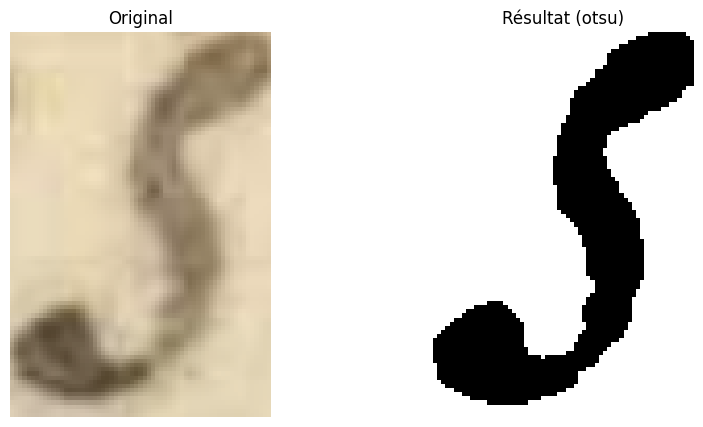

Si le résultat vous convient, passez à la cellule suivante. Sinon, ajustez METHOD / THRESHOLD_VALUE / INVERT ci-dessus et relancez cette cellule.


In [ ]:
# --- CELLULE 4 : Aperçu sur une image avant de tout lancer ---
if image_files:
    sample_path = os.path.join(INPUT_DIR, image_files[0])
    sample_img = cv2.imread(sample_path)
    sample_gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)
    sample_result = apply_threshold(sample_gray)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(sample_result, cmap="gray")
    axes[1].set_title(f"Résultat ({METHOD})")
    axes[1].axis("off")
    plt.show()

    print("Si le résultat vous convient, passez à la cellule suivante. "
          "Sinon, ajustez METHOD / THRESHOLD_VALUE / INVERT ci-dessus et "
          "relancez cette cellule.")

In [ ]:
# --- CELLULE 5 : Traitement de toutes les images ---
processed_count = 0
errors = []

for fname in image_files:
    try:
        path = os.path.join(INPUT_DIR, fname)
        img = cv2.imread(path)
        if img is None:
            errors.append(fname)
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result = apply_threshold(gray)

        out_name = os.path.splitext(fname)[0] + "_thresh.png"
        cv2.imwrite(os.path.join(OUTPUT_DIR, out_name), result)
        processed_count += 1
    except Exception as e:
        errors.append(f"{fname} ({e})")

print(f"\n{processed_count} images traitées avec succès.")
if errors:
    print(f"{len(errors)} erreurs : {errors}")


128 images traitées avec succès.


In [ ]:
# --- CELLULE 6 : Zipper et télécharger le résultat ---
zip_name = "images_thresholded.zip"
shutil.make_archive("images_thresholded", "zip", OUTPUT_DIR)
files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>